# ch241 — Randomness

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. What Randomness Actually Is

"Random" is not a synonym for "unknown" or "unpredictable by humans." In mathematics, a process is random if its outcomes cannot be determined in advance — not because we lack information, but because the outcome genuinely varies across repeated identical setups.

There are two positions on randomness:

**Frequentist**: Randomness is a property of a repeatable physical process. Flip a fair coin infinitely many times — heads appears in exactly 50% of them. Probability is a limiting frequency.

**Bayesian**: Randomness is a description of epistemic state — our uncertainty about what will happen. Probability quantifies degree of belief, not physical frequency.

Both views produce the same mathematics. The distinction matters when interpreting results. This book uses both where appropriate.

---

## 2. Pseudorandomness in Computing

Computers are deterministic. They cannot produce true randomness. What they produce is **pseudorandomness**: a sequence that passes statistical tests for randomness but is generated by a deterministic algorithm.

The algorithm is called a **Pseudorandom Number Generator (PRNG)**. Given an identical seed, it produces an identical sequence.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Same seed => same sequence, every time
rng = np.random.default_rng(seed=42)
sequence_a = rng.integers(1, 7, size=10)  # ten rolls of a d6

rng2 = np.random.default_rng(seed=42)
sequence_b = rng2.integers(1, 7, size=10)

print("Sequence A:", sequence_a)
print("Sequence B:", sequence_b)
print("Identical:", np.array_equal(sequence_a, sequence_b))

Sequence A: [1 5 4 3 3 6 1 5 2 1]
Sequence B: [1 5 4 3 3 6 1 5 2 1]
Identical: True


Always use `numpy.random.default_rng()` rather than the legacy `numpy.random.seed()` interface. The new API produces a Generator object with better statistical properties (PCG64 algorithm) and explicit state management.

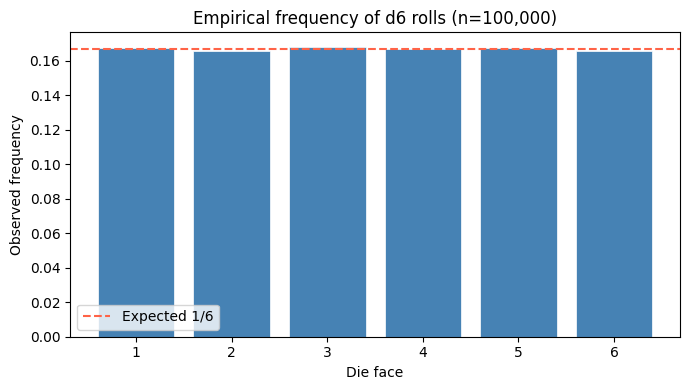


Observed frequencies:
  Face 1: 0.1672  (deviation from 1/6: 0.0005)
  Face 2: 0.1653  (deviation from 1/6: 0.0014)
  Face 3: 0.1680  (deviation from 1/6: 0.0013)
  Face 4: 0.1669  (deviation from 1/6: 0.0003)
  Face 5: 0.1673  (deviation from 1/6: 0.0006)
  Face 6: 0.1654  (deviation from 1/6: 0.0013)


In [2]:
# Empirical demonstration: does 'random' actually spread uniformly?
rng = np.random.default_rng(seed=0)
n = 100_000
rolls = rng.integers(1, 7, size=n)  # 1 through 6 inclusive

values, counts = np.unique(rolls, return_counts=True)
frequencies = counts / n

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(values, frequencies, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axhline(1/6, color='tomato', linestyle='--', label='Expected 1/6')
ax.set_xlabel('Die face')
ax.set_ylabel('Observed frequency')
ax.set_title(f'Empirical frequency of d6 rolls (n={n:,})')
ax.legend()
plt.tight_layout()
plt.show()

print("\nObserved frequencies:")
for v, f in zip(values, frequencies):
    print(f"  Face {v}: {f:.4f}  (deviation from 1/6: {abs(f - 1/6):.4f})")

## 3. Sources of Randomness

| Source | Type | Use case |
|--------|------|----------|
| PRNG (PCG64, Mersenne Twister) | Pseudorandom | Simulations, ML training |
| OS entropy (`/dev/urandom`) | Cryptographically secure | Keys, tokens |
| Hardware RNG (thermal noise) | True random | High-security applications |
| Quantum processes | True random | Research |

For scientific computing and ML, PRNGs are entirely sufficient. Use `secrets` or `os.urandom` when security is the concern.

In [3]:
import secrets

# Cryptographically secure random integer in [0, n)
secure_token = secrets.token_hex(16)
print("Secure token:", secure_token)

# For reproducible science, always use numpy with an explicit seed
rng = np.random.default_rng(seed=2024)
print("First draw:", rng.uniform(0, 1))
print("Second draw:", rng.uniform(0, 1))

Secure token: d7d7f84893e00c73e85006b6543fdce6
First draw: 0.6758313379812818
Second draw: 0.21432320123825765


## 4. Testing Randomness: Basic Statistical Tests

How do you know a sequence is "random enough"? Apply tests. A good PRNG should:
- Produce each value with equal frequency (uniformity)
- Show no autocorrelation (successive values are independent)
- Pass the chi-squared goodness-of-fit test

In [4]:
from scipy import stats

rng = np.random.default_rng(seed=99)
n = 10_000
rolls = rng.integers(1, 7, size=n)

# Chi-squared test: are observed frequencies consistent with uniform distribution?
observed = np.bincount(rolls, minlength=7)[1:]   # counts for faces 1-6
expected = np.full(6, n / 6)

chi2_stat, p_value = stats.chisquare(observed, expected)
print(f"Chi-squared statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Conclusion: {'Cannot reject uniformity' if p_value > 0.05 else 'Reject uniformity'}")

# Autocorrelation: does knowing roll[i] tell you anything about roll[i+1]?
# Pearson correlation between consecutive pairs
x = rolls[:-1].astype(float)
y = rolls[1:].astype(float)
corr, p_corr = stats.pearsonr(x, y)
print(f"\nAutocorrelation (lag-1): {corr:.4f}  (p={p_corr:.4f})")
print("Near zero means successive rolls are independent.")

Chi-squared statistic: 3.9788
p-value: 0.5525
Conclusion: Cannot reject uniformity

Autocorrelation (lag-1): -0.0026  (p=0.7927)
Near zero means successive rolls are independent.


## 5. Randomness Is the Foundation of Probability

Probability theory is the formal study of random processes. Every construct in the next 29 chapters — events, distributions, expectations, Markov chains — is built on top of the simple fact that outcomes vary.

The key insight: even though individual outcomes are unpredictable, **aggregate behavior is highly regular**. Roll one die and you cannot know the outcome. Roll a million dice and the average is almost certainly within 0.01 of 3.5. This regularity is what makes probability useful.

*(The precise statement of this regularity is the Law of Large Numbers — see ch255.)*

---

## 6. Summary

- Randomness in computing is pseudorandom: deterministic, reproducible with a seed, but statistically indistinguishable from true random.
- Use `numpy.random.default_rng(seed)` for reproducible scientific simulations.
- Statistical tests (chi-squared, autocorrelation) verify quality of random sequences.
- Probability is the mathematical framework for reasoning about random processes — individual outcomes are unpredictable; aggregate behavior is precisely characterizable.

---

## 7. Forward References

This chapter introduced the computational infrastructure for randomness. The mathematical structure — what outcomes are possible and how probability is assigned — begins in ch242 (Sample Spaces). The regularity of large samples is formalized in ch255 (Law of Large Numbers). Every simulation in ch256–ch259 draws on the PRNG patterns established here.